In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

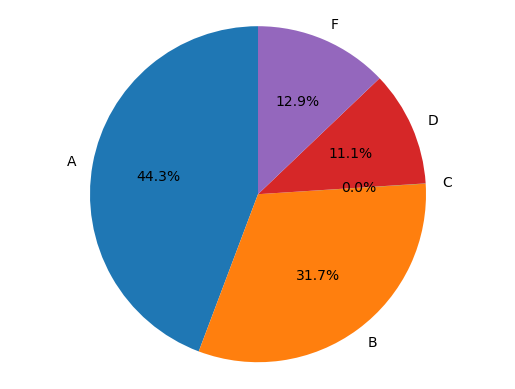

In [5]:
import matplotlib.pyplot as plt

labels = ['A', 'B', 'C', 'D', 'F']
counts = df['ocean_proximity'].value_counts().sort_index()

plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')  # circle
plt.show()


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df.shape

(20640, 10)

In [8]:
# Fill the null values 

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [9]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [10]:
# Label Encoding 

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

In [11]:
# Convert the values in the range 0 to 1

from sklearn.preprocessing import MinMaxScaler

features = ['longitude', 'latitude', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']

scaler = MinMaxScaler()

for col in features:
    df[col] = scaler.fit_transform(df[[col]])

In [12]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0.211155,0.567481,41.0,0.022331,0.019863,0.008941,0.020556,0.539668,0.902266,3
1,0.212151,0.565356,21.0,0.180503,0.171477,0.067210,0.186976,0.538027,0.708247,3
2,0.210159,0.564293,52.0,0.037260,0.029330,0.013818,0.028943,0.466028,0.695051,3
3,0.209163,0.564293,52.0,0.032352,0.036313,0.015555,0.035849,0.354699,0.672783,3
4,0.209163,0.564293,52.0,0.041330,0.043296,0.015752,0.042427,0.230776,0.674638,3
...,...,...,...,...,...,...,...,...,...,...
20635,0.324701,0.737513,25.0,0.042296,0.057883,0.023599,0.054103,0.073130,0.130105,1
20636,0.312749,0.738576,18.0,0.017676,0.023122,0.009894,0.018582,0.141853,0.128043,1
20637,0.311753,0.732200,17.0,0.057277,0.075109,0.028140,0.071041,0.082764,0.159383,1
20638,0.301793,0.732200,18.0,0.047256,0.063315,0.020684,0.057227,0.094295,0.143713,1


In [13]:
# Now Convert the values X and y

X = df.drop(columns = 'median_house_value')
y = df['median_house_value']

In [14]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,0.211155,0.567481,41.0,0.022331,0.019863,0.008941,0.020556,0.539668,3
1,0.212151,0.565356,21.0,0.180503,0.171477,0.067210,0.186976,0.538027,3
2,0.210159,0.564293,52.0,0.037260,0.029330,0.013818,0.028943,0.466028,3
3,0.209163,0.564293,52.0,0.032352,0.036313,0.015555,0.035849,0.354699,3
4,0.209163,0.564293,52.0,0.041330,0.043296,0.015752,0.042427,0.230776,3


In [15]:
# Split the data into Train and Test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [16]:
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14196,0.729084,0.018066,33.0,0.079455,0.097145,0.064380,0.102286,0.190322,4
8267,0.616534,0.130712,49.0,0.085966,0.121974,0.036744,0.124157,0.228452,4
17445,0.385458,0.225292,4.0,0.048197,0.051210,0.025561,0.055090,0.252162,4
14265,0.721116,0.015940,36.0,0.036090,0.056797,0.039659,0.058214,0.099488,4
2271,0.453187,0.450584,43.0,0.060532,0.066729,0.024412,0.062325,0.210638,1


In [17]:
# Train the Model 
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [18]:
# Predict the Output 

from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print("Accuracy Score : ", r2_score(y_test, y_pred))

Accuracy Score :  0.6142406531011786
